In [ ]:
import pandas as pd
import re
import networkx as nx
import urllib
from pathlib import Path
from urllib.parse import unquote
import random
from collections import Counter
import numpy as np
import seaborn as sns
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# Assignment 2: Network Communities, Text Analysis, and Sentiment

**Course:** Social Graphs and Interactions (02805)  
**Semester:** Spring 2025  
**Technical University of Denmark**

---

## Group Information

**Group Members:**
- Thor Nørgaard Eriksen (s204618)
- Søren Mondrup (s214983)

---

## Introduction

[Provide an introduction to Assignment 2, describing the focus on network analysis, community detection, TF-IDF text analysis, and sentiment analysis of the Rock Musicians network from Assignment 1.]

---

## Assignment Structure

1. **Part 1:** Analyze the Network
2. **Part 2:** Genres and Communities and Plotting
3. **Part 3:** TF-IDF to Understand Genres and Communities
4. **Part 4:** Sentiment of the Artists and Communities

---

# Part 1: Analyze the Network

This section presents an analysis of the network of bands/artists using concepts from network science, including centrality measures, assortativity, and network backbones.

## 1.1 Network Overview and Basic Properties

## 1.2 Degree Distribution Analysis

## 1.3 Centrality Analysis

## 1.4 Assortativity Analysis

## 1.5 Network Backbone Construction

## 1.6 Network Visualization

## 1.7 Summary of Network Characteristics

---

# Part 2: Genres and Communities and Plotting

This section explores the relationship between musical genres and detected communities, examining modularity and creating visualizations.

## 2.1 Genres and Modularity
The modularity describes how a community structure in a network is more or less strongly divided than if we just made the communities at random. So if the communities have more of their edges internally than would be expected from a randomly wired network of the same N nodes and L links it gets a positive modularity. On the other hand, a community definition which splits more edges between communities than the random wiring will have a negative modularity.

Shown in [Barabasi - Image 9.16] are two different community partitions. In partition **a** most edges stay within communities (only 1 edge crosses between green and purple), giving M = 0.41. In partition **b**, more edges cross between communities (3 edges), resulting in lower modularity M = 0.22. Both outperform random (M $\approx$ 0), but **a** is the better partition. **d** which only has inter

Using the measure of modularity we can now quantify how well our previous partitions perform on our Rock network compared to the genres defined on the wiki-page of the artist.

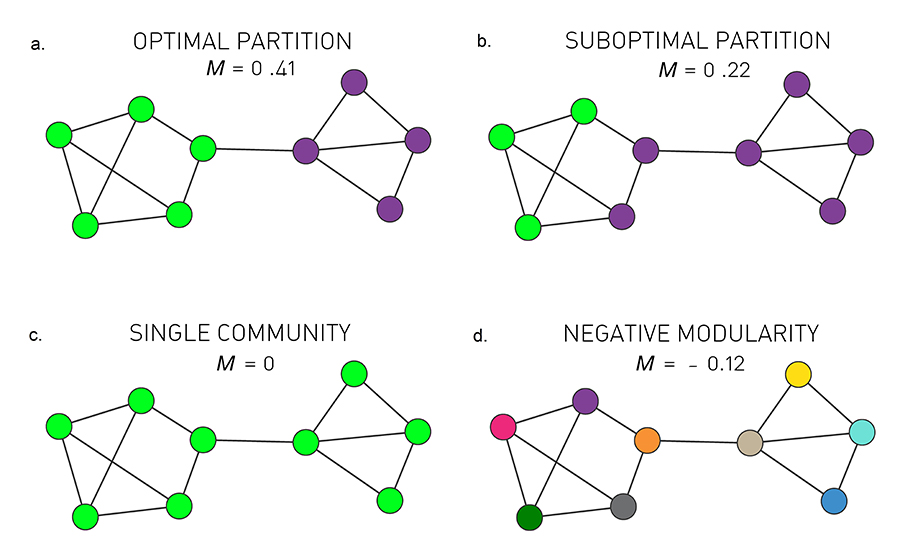

**Reference:** Barabási, A.-L. (2016). Network Science, Chapter 9, Section 9.4 and Image 9.16

First we define the function to find the modularity based on Barabási equation $(9.11)$ and $(9.12)$

In [37]:
def calculate_modularity(G, communities, verbose=False):
    """
    Compute Newman-Girvan modularity for an undirected graph G given a partition.
    """
    
    L = G.number_of_edges()
    M = 0
    
    for community_label, nodes in communities.items():
        # Internal edges in community
        Lc = G.subgraph(nodes).number_of_edges()
        
        # Sum of degrees in community
        kc = sum(G.degree(node) for node in nodes if node in G)
        
        left = Lc / L
        right = (kc / (2 * L)) ** 2
        Mc = left - right
        M += Mc
        
        if verbose:
            print(f"Community '{community_label}':")
            print(f"  Internal edges (Lc): {Lc}")
            print(f"  Total degree (kc): {kc}")
            print(f"  Modularity contribution (Mc): {Mc:.4f}")    
    return M

## 2.3 Modularity Comparison: Communities vs. Genres

In Section 1 we found the structural communities in the network by using the Louvain Community Detection Algorithm, before we can compare them to the genre definitions we need to retrieve those from the .txt files.

In [59]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/graphs/rock_bands_graph.gexf") as response:
    DG = nx.read_gexf(response)

G = DG.to_undirected()

with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/graphs/node_df.csv") as response:
    node_df = pd.read_csv(response)

def extract_genres(text):
    """Extract genres from Wikipedia infobox text."""
    # Remove HTML comments
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    
    # Find infobox
    infobox = re.search(r'\{\{Infobox musical artist(.*?)(?=\n\{\{[^I]|\Z)', text, re.DOTALL)
    if not infobox:
        return []
    
    # Find genre field
    lines = infobox.group(1).split('\n')
    genre_lines = []
    in_genre = False
    
    for line in lines:
        if line.strip().startswith('|'):
            field = re.match(r'\|\s*(\w+)\s*=', line)
            if field and field.group(1) == 'genre':
                in_genre = True
                genre_lines.append(line.split('=', 1)[1] if '=' in line else '')
            else:
                in_genre = False
        elif in_genre and not line.strip().startswith('}}'):
            genre_lines.append(line)
    
    if not genre_lines:
        return []
    
    # Extract wikilinks
    genre_text = '\n'.join(genre_lines)
    genre_text = re.sub(r'<ref[^>]*>.*?</ref>', '', genre_text, flags=re.DOTALL)
    
    genres = []
    for link in re.findall(r'\[\[([^\]]+?)\]\]', genre_text):
        genre = link.split('|')[-1] if '|' in link else link
        genre = re.sub(r'\s*\([^)]*\)', '', genre).strip()
        
        # Skip non-genres
        skip = ['Records', 'Label', 'Music', 'Radio', 'Journal', 'Magazine']
        if genre and not any(s in genre for s in skip):
            genres.append(genre)
    
    return genres


def parse_artist_files(directory):
    """Parse all artist .txt files in a directory. Returns dict: {artist_name: [genres]}"""
    artist_genres = {}
    
    for file_path in Path(directory).glob("*.txt"):
        # Get artist name from filename
        name = file_path.stem
        name = re.sub(r'^\d+_', '', name)  # Remove timestamp
        name = name.replace('_20', ' ').replace('_28', '(').replace('_29', ')')
        
        if name in artist_genres:  # Skip duplicates
            continue
        
        with open(file_path, 'r', encoding='utf-8') as f:
            artist_genres[name] = extract_genres(f.read())
    
    return artist_genres

# Parse files (parse_artist_files is defined in an earlier cell)
artist_genres = parse_artist_files('rock_data')

# Normalize possible percent-encoded or underscore-encoded filenames to readable artist names
fixed_artist_genres = {}
for artist, genres in artist_genres.items():
    name = unquote(artist)                         # decode percent-encoding (e.g. %20 -> space)
    name = name.replace('_20', ' ').replace('_28', '(').replace('_29', ')')
    name = re.sub(r'^\d+_', '', name)             # remove leading timestamp if present
    fixed_artist_genres[name] = genres


# Parse files (parse_artist_files is defined in an earlier cell)
artist_genres = parse_artist_files('rock_data')

# Normalize possible percent-encoded or underscore-encoded filenames to readable artist names
fixed_artist_genres = {}
for artist, genres in artist_genres.items():
    name = unquote(artist)                         # decode percent-encoding (e.g. %20 -> space)
    name = name.replace('_20', ' ').replace('_28', '(').replace('_29', ')')
    name = re.sub(r'^\d+_', '', name)             # remove leading timestamp if present
    fixed_artist_genres[name] = genres


# Add genre columns to node_df
node_df['first_genre'] = node_df['Node'].apply(
    lambda x: fixed_artist_genres.get(x, [None])[0] if fixed_artist_genres.get(x, []) else None
)

node_df['random_genre'] = node_df['Node'].apply(
    lambda x: random.choice(fixed_artist_genres.get(x, [None])) if fixed_artist_genres.get(x, []) else None
)

In [60]:
node_df

,Node,In Degree,Out Degree,Degree Centrality,Betweenness Centrality,Eigenvector Centrality,Avg Neighbour Degree,Content Length,Louvain,first_genre,random_genre
0,10 Years (band),7,10,0.03696,0.00089,0.01243,23.900000,4501,3.0,Alternative metal,progressive metal
1,Disturbed (band),20,33,0.11522,0.00462,0.03755,23.787879,11700,3.0,Heavy metal,hard rock
2,Breaking Benjamin,21,33,0.11739,0.00648,0.02216,22.303030,16494,3.0,Hard rock,alternative rock
3,Mudvayne,7,15,0.04783,0.00038,0.01956,33.333333,7843,1.0,Alternative metal,nu metal
4,Korn,38,34,0.15652,0.00876,0.08627,26.205882,30035,3.0,Nu metal,alternative metal
...,...,...,...,...,...,...,...,...,...,...,...
456,The Jesus and Mary Chain,1,13,0.03043,0.00035,0.00310,15.307692,9465,0.0,Noise pop,indie rock
457,Smash Mouth,1,14,0.03261,0.00019,0.00027,18.571429,9336,3.0,Alternative rock,pop rock
458,Smokie (band),1,2,0.00652,0.00010,0.00157,17.500000,4730,4.0,Pop rock,Pop rock
459,The Fray,2,11,0.02826,0.00025,0.00112,14.545455,8889,0.0,Alternative rock,soft rock


To avoid skewing the results unfairly towards the Louvain results, we need to handle nodes which are missing genre information (either through imprecise scraping or lack of genres in the article). Since they account for only 5% of the network we chose to drop them.

In [61]:
filtered_nodes_df = node_df.dropna(subset=['first_genre'])

In [63]:
# Create three different community partitions

# 1. Louvain communities
louvain_communities = {}
for _, row in filtered_nodes_df.iterrows():
    community_label = f"Louvain_{int(row['Louvain'])}"
    if community_label not in louvain_communities:
        louvain_communities[community_label] = []
    louvain_communities[community_label].append(row['Node'])

# 2. First genre communities
first_genre_communities = {}
for _, row in filtered_nodes_df.iterrows():
    if pd.notna(row['first_genre']):
        genre = row['first_genre']
        if genre not in first_genre_communities:
            first_genre_communities[genre] = []
        first_genre_communities[genre].append(row['Node'])

# 3. Random genre communities
random_genre_communities = {}
for _, row in filtered_nodes_df.iterrows():
    if pd.notna(row['random_genre']):
        genre = row['random_genre']
        if genre not in random_genre_communities:
            random_genre_communities[genre] = []
        random_genre_communities[genre].append(row['Node'])

# Calculate modularity for each partition
modularity_louvain = calculate_modularity(G, louvain_communities, verbose=False)

modularity_first_genre = calculate_modularity(G, first_genre_communities, verbose=False)

modularity_random_genre = calculate_modularity(G, random_genre_communities, verbose=False)

# Create a summary dataframe
modularity_summary = pd.DataFrame({
    'Partition': ['Louvain', 'First Genre', 'Random Genre'],
    'Modularity': [modularity_louvain, modularity_first_genre, modularity_random_genre],
    'Num Communities': [len(louvain_communities), len(first_genre_communities), 
                        len(random_genre_communities)]
})

# Print summary statistics
print("Community Partition Summary:")
print(modularity_summary.to_string(index=False))

Community Partition Summary:
   Partition  Modularity  Num Communities
     Louvain    0.301791                5
 First Genre    0.087014               77
Random Genre    0.017266              139


Structural community detection (M = 0.302) dramatically outperforms genre-based partitions. The Louvain algorithm identifies 5 cohesive communities, while genre classifications fragment the network into 77-139 disconnected groups with poor modularity.

When randomly assigning genres to artists (M = 0.017, 139 communities), modularity approaches zero. This confirms that meaningful partitions require actual network structure, not arbitrary labels. The first-genre partition (M = 0.087) performs better than random but still fails to capture the network's modular organization.

The $\approx 3.5x$ improvement in modularity (0.302 vs 0.087) demonstrates that using the inherent structure of the network (who connects with whom), reveals community structure far better than editorial genre classifications made by wikipedia editors.

## 2.4 Calculating and Analyzing Matrix D

Top 7 genres:
  Rock: 64
  Alternative rock: 57
  Hard rock: 50
  Pop rock: 19
  Heavy metal: 16
  Progressive rock: 15
  Rock and roll: 13

Top 7 communities:
  Louvain_2: 144 nodes
  Louvain_0: 111 nodes
  Louvain_3: 96 nodes
  Louvain_1: 68 nodes
  Louvain_4: 42 nodes


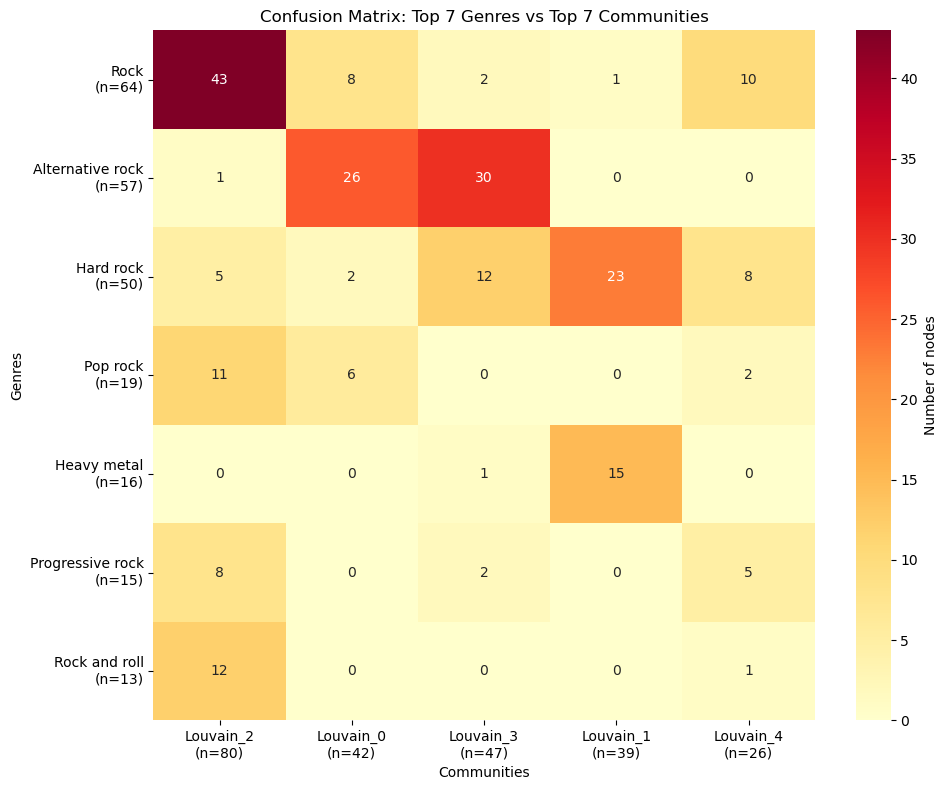

In [64]:
# Count how many artists belong to each genre
genre_counts = Counter()
for _, row in node_df.iterrows():
    if pd.notna(row['first_genre']):
        genre_counts[row['first_genre']] += 1

# Get top 7 genres
G = genre_counts.most_common(7)

# Get top 7 communities from Louvain (based on size)
louvain_counts = node_df['Louvain'].value_counts()
C = [(f"Louvain_{int(comm)}", count) for comm, count in louvain_counts.head(7).items()]

# Print top 7 genres and communities
print("Top 7 genres:")
for genre, count in G:
    print(f"  {genre}: {count}")

print(f"\nTop 7 communities:")
for label, size in C:
    print(f"  {label}: {size} nodes")

# Create confusion matrix D (G x C)

# Extract just the names
top_genres = [g[0] for g in G]
top_communities = [c[0] for c in C]

# Initialize confusion matrix
D = np.zeros((len(top_genres), len(top_communities)))

# Fill confusion matrix
for i, genre in enumerate(top_genres):
    for j, comm_label in enumerate(top_communities):
        # Count nodes that have this genre AND are in this community
        count = len(node_df[
            (node_df['first_genre'] == genre) & 
            (node_df['Louvain'] == int(comm_label.split('_')[1]))
        ])
        
        D[i, j] = count

# Calculate row and column sums
row_sums = D.sum(axis=1)
col_sums = D.sum(axis=0)

# Create labels with sums
row_labels = [f"{genre}\n(n={int(s)})" for genre, s in zip(top_genres, row_sums)]
col_labels = [f"{comm}\n(n={int(s)})" for comm, s in zip(top_communities, col_sums)]

# Create DataFrame for better visualization
D_df = pd.DataFrame(D, index=row_labels, columns=col_labels)

# Visualize as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(D_df, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Number of nodes'})
plt.title('Confusion Matrix: Top 7 Genres vs Top 7 Communities')
plt.xlabel('Communities')
plt.ylabel('Genres')
plt.tight_layout()
plt.show()


## 2.5 Visualization of Communities

---

# Part 3: TF-IDF to Understand Genres and Communities

This section applies TF-IDF (Term Frequency-Inverse Document Frequency) analysis to understand the linguistic characteristics of genres and communities.

## 3.1 Explanation of TF-IDF

When analysing the found communities an interesting aspect is the linguistical characteristics that they share, but even more interesting are the contrasts between the various communities. Working with the Wikipedia-articles as a proxy of what defines a band and aggregating that across our communities allows us the use of TF-IDF to say what words are particularly important for each community.

TF-IDF works by multiplying the term frequency (TF) which is a measure of how many times the term appears in a document (With the document here being the collected articles across the community) with the inverse document frequency (IDF) which measures how common the word is across the entire corpus (Every article in the entire network). This way very frequent words like band or album which have the highest TF in all communities but tell us nothing about the differences are filtered out because even if they have very high TF their IDF is 0 ($ln(1)$). In contrast, a term which occurs much less frequently across the corpus, but has a higher IDF must mean that the term is endemic to this specific community, which is a lot more interesting for our analysis.

## 3.2 TF-IDF Calculation for Genres

In [66]:
# Ensure required NLTK data is available
try:
    nltk.data.find('corpora/wordnet')
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('wordnet')
    nltk.download('punkt')
    nltk.download('stopwords')

def simple_lemmatize(word):
    """Lemmatize by trying noun, verb, and adjective forms"""
    lemmatizer = WordNetLemmatizer()
    # Try as noun first (most common)
    lemma = lemmatizer.lemmatize(word, pos='n')
    if lemma == word:
        # If unchanged, try as verb
        lemma = lemmatizer.lemmatize(word, pos='v')
    if lemma == word:
        # If still unchanged, try as adjective
        lemma = lemmatizer.lemmatize(word, pos='a')
    return lemma

def preprocess_text(text):
    """Clean and tokenize text"""
    text = re.sub(r'\{\{[^}]*\}\}', '', text)  # Remove templates
    text = re.sub(r'\[\[([^\]|]+\|)?([^\]]+)\]\]', r'\2', text)  # Remove wiki links
    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML tags
    text = re.sub(r'&[a-zA-Z]+;', '', text)  # Remove HTML entities
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    text = text.lower()  # Convert to lowercase
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Lemmatize
    tokens = [simple_lemmatize(token) for token in tokens]
    
    # Filter: only words with 2+ characters
    tokens = [token for token in tokens if len(token) > 2]
    
    # Remove stopwords and common music words
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stopwords]
    
    return tokens

def calculate_tfidf_for_communities(communities_dict, top_n=10):
    """
    Calculate TF-IDF scores for communities based on artist Wikipedia articles.
    
    Parameters:
    communities_dict: dict mapping community labels to lists of artist names
    top_n: int, number of top words to return for each community
    
    Returns:
    dict: mapping community labels to lists of (word, tfidf_score) tuples
    """
    base_url = "https://raw.githubusercontent.com/Somon8/social_graphs_25/main/rock_data"
    
    # Step 1: Collect and tokenize documents for each community
    community_labels = []
    community_tokens = {}  # {community: [list of tokens]}
    
    for community_label, artists in communities_dict.items():
        all_tokens = []
        
        for artist in artists:
            filename = urllib.parse.quote(artist, safe="") + ".txt"
            file_url = f"{base_url}/{filename}"
            
            try:
                with urllib.request.urlopen(file_url) as response:
                    content = response.read().decode("utf-8")
                    tokens = preprocess_text(content)
                    all_tokens.extend(tokens)
            except:
                continue
        
        if all_tokens:
            community_tokens[community_label] = all_tokens
            community_labels.append(community_label)
    
    # Step 2: Calculate TF (Term Frequency) for each community
    community_tf = {}
    for community, tokens in community_tokens.items():
        token_counts = Counter(tokens)
        total_tokens = len(tokens)
        # TF = count / total_tokens
        tf = {word: count / total_tokens for word, count in token_counts.items()}
        community_tf[community] = tf
    
    # Step 3: Calculate IDF (Inverse Document Frequency)
    # IDF(word) = log(total_communities / communities_containing_word)
    word_document_counts = Counter()
    for community, tokens in community_tokens.items():
        unique_words = set(tokens)
        for word in unique_words:
            word_document_counts[word] += 1
    
    total_documents = len(community_labels)
    word_idf = {}
    for word, doc_count in word_document_counts.items():
        idf = np.log(total_documents / doc_count)
        word_idf[word] = idf
    
    # Step 4: Calculate TF-IDF for each community
    results = {}
    for community in community_labels:
        tf = community_tf[community]
        tfidf_scores = {}
        
        for word, tf_score in tf.items():
            idf_score = word_idf.get(word, 0)
            tfidf_scores[word] = tf_score * idf_score
        
        # Get top N words
        top_words = sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
        results[community] = top_words
    
    return results

[nltk_data] Downloading package wordnet to /Users/mondrup/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/mondrup/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mondrup/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
genre_tfidf = calculate_tfidf_for_communities(first_genre_communities, top_n=10)


In [ ]:
for community, top_words in genre_tfidf.items():
    print(f"\n{community}:")
    for word, score in top_words:
        print(f"  {word}: {score:.4f}")

## 3.3 TF-IDF Calculation for Communities

In [ ]:
louvain_tfidf = calculate_tfidf_for_communities(louvain_communities, top_n=10)

In [ ]:
for community, top_words in louvain_tfidf.items():
    print(f"\n{community}:")
    for word, score in top_words:
        print(f"  {word}: {score:.4f}")

## 3.4 Visualization of TF-IDF Results

## 3.5 Comparison Using Matrix D

---

# Part 4: Sentiment of the Artists and Communities

This section analyzes the sentiment of artist/band Wikipedia pages and explores how sentiment varies across communities.

## 4.1 Sentiment Calculation for Artist Pages

In [12]:
import pandas as pd
from IPython.display import display

labmt = pd.read_csv('lbmt_valence.txt', sep='\t', skiprows=3, header=0)
print(f"LabMT shape: {labmt.shape[0]:,} rows x {labmt.shape[1]} columns")
print("Columns:", ", ".join(labmt.columns))

with pd.option_context('display.max_columns', None, 'display.width', 0):
    print("\nFirst 5 rows (most positive words):")
    display(labmt.head())
    print("\nLast 5 rows:")
    display(labmt.tail())

LabMT shape: 10,222 rows x 8 columns
Columns: word, happiness_rank, happiness_average, happiness_standard_deviation, twitter_rank, google_rank, nyt_rank, lyrics_rank

First 5 rows (most positive words):


,word,happiness_rank,happiness_average,happiness_standard_deviation,twitter_rank,google_rank,nyt_rank,lyrics_rank
0,laughter,1,8.50,0.9313,3600,--,--,1728
1,happiness,2,8.44,0.9723,1853,2458,--,1230
2,love,3,8.42,1.1082,25,317,328,23
3,happy,4,8.30,0.9949,65,1372,1313,375
4,laughed,5,8.26,1.1572,3334,3542,--,2332



Last 5 rows:


,word,happiness_rank,happiness_average,happiness_standard_deviation,twitter_rank,google_rank,nyt_rank,lyrics_rank
10217,murder,10218,1.48,1.0150,2762,3110,1541,1059
10218,terrorism,10219,1.48,0.9089,--,--,3192,--
10219,rape,10220,1.44,0.7866,3133,--,4115,2977
10220,suicide,10221,1.30,0.8391,2124,4707,3319,2107
10221,terrorist,10222,1.30,0.9091,3576,--,3026,--


Defining a function that will take any list of tokens and return the average sentiment. Inspired by SOURCE we also include the option of a delta parameter which will remove neutrally laden words within $[5-\delta, 5+\delta]$ theoretically this increases the signal in the sample, making the differences statistically clearer.

In [13]:
def calculate_sentiment(tokens, delta=0, verbose=False):
    """
    Calculate sentiment given a list of tokens.
    
    Parameters:
    tokens: list of strings (will be converted to lowercase)
    delta: float, removes words with happiness scores within delta of 5 (neutral)
           For example, delta=1 removes words with scores between 4 and 6
    verbose: bool, print detailed information
    
    Returns:
    float: average sentiment score
    """
    # Create a dictionary for faster lookup
    sentiment_dict = dict(zip(labmt['word'], labmt['happiness_average']))
    
    # Apply delta filter: keep only words outside the neutral range [5-delta, 5+delta]
    if delta > 0:
        sentiment_dict = {
            word: score 
            for word, score in sentiment_dict.items() 
            if abs(score - 5) > delta
        }
    
    # Convert tokens to lowercase
    tokens = [token.lower() for token in tokens]
    
    # Get sentiment scores for tokens that exist in filtered LabMT
    sentiments = [sentiment_dict[token] for token in tokens if token in sentiment_dict]
    
    # Calculate average sentiment
    if sentiments:
        avg_sentiment = sum(sentiments) / len(sentiments)
    else:
        raise ValueError("No sentiments found: none of the tokens matched the LabMT lexicon.")
    
    # Print individual scores for short lists
    if verbose and len(tokens) <= 20:
        print(f"Using delta={delta} (removing words with scores between {5-delta} and {5+delta})")
        print("Individual word sentiments:")
        for token in tokens:
            if token in sentiment_dict:
                print(f"  {token}: {sentiment_dict[token]:.2f}")
            else:
                original_score = dict(zip(labmt['word'], labmt['happiness_average'])).get(token)
                if original_score is not None:
                    print(f"  {token}: {original_score:.2f} (filtered out by delta)")
                else:
                    print(f"  {token}: not found in LabMT")
        print(f"\nAverage sentiment: {avg_sentiment:.2f}")
        print(f"Words used in calculation: {len(sentiments)}/{len(tokens)}")
    elif verbose:
        print(f"Using delta={delta}")
        print(f"Average sentiment: {avg_sentiment:.2f}")
        print(f"Words used: {len(sentiments)}/{len(tokens)}")
    
    return avg_sentiment

# Example usage:
print("Without delta filter:")
_ = calculate_sentiment(['happy', 'the', 'or', 'angry'], delta=0, verbose=True)

print("\n" + "="*50 + "\n")

print("With delta=1 filter:")
_ = calculate_sentiment(['happy', 'the', 'or', 'angry'], delta=1, verbose=True)

Without delta filter:
Using delta=0 (removing words with scores between 5 and 5)
Individual word sentiments:
  happy: 8.30
  the: 4.98
  or: 4.98
  angry: 2.32

Average sentiment: 5.15
Words used in calculation: 4/4


With delta=1 filter:
Using delta=1 (removing words with scores between 4 and 6)
Individual word sentiments:
  happy: 8.30
  the: 4.98 (filtered out by delta)
  or: 4.98 (filtered out by delta)
  angry: 2.32

Average sentiment: 5.31
Words used in calculation: 2/4


In [14]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/graphs/rock_bands_graph.gexf") as response:
    DG = nx.read_gexf(response)

G = DG.to_undirected()

In [ ]:
base_url = "https://raw.githubusercontent.com/Somon8/social_graphs_25/main/rock_data"

# Create dictionaries to store sentiment scores for different delta values
artist_sentiments_by_delta = {}

for delta in [0, 0.5, 1, 1.5, 2]:
    artist_sentiments_by_delta[delta] = {}
    for node in DG.nodes():
        filename = urllib.parse.quote(node, safe="") + ".txt"
        file_url = f"{base_url}/{filename}"
        try:
            with urllib.request.urlopen(file_url) as resp:
                content = resp.read().decode("utf-8")
        except Exception:
            # If the file is not found or another error occurs, store NaN
            artist_sentiments_by_delta[delta][node] = float("nan")
            continue

        tokens = word_tokenize(content)
        try:
            sentiment = calculate_sentiment(tokens, delta=delta)
        except ValueError:
            sentiment = float("nan")
        artist_sentiments_by_delta[delta][node] = sentiment

# For backward compatibility, keep the original variable
artist_sentiments = artist_sentiments_by_delta[0]

In [32]:
import pickle

# Save artist_sentiments dictionary as a pickle file
with open('artist_sentiments.pkl', 'wb') as f:
    pickle.dump(artist_sentiments, f)

print(f"Saved sentiment scores for {len(artist_sentiments)} artists to 'artist_sentiments.pkl'")

Saved sentiment scores for 461 artists to 'artist_sentiments.pkl'


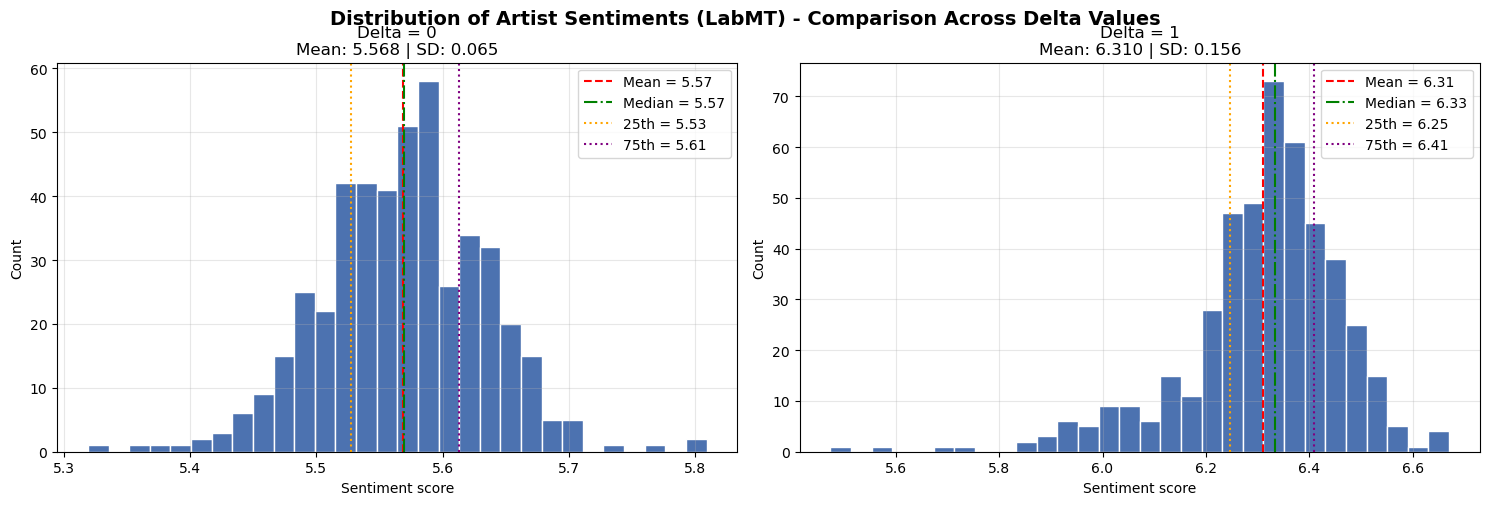


DELTA = 0
Total artists: 461

Bottom 10 artists:
Five Finger Death Punch     5.319183
Rage Against the Machine    5.368000
Rob Zombie                  5.370736
Marilyn Manson              5.399926
Quiet Riot                  5.400872
Canned Heat                 5.405595
Gary Glitter                5.418688
Skid Row (American band)    5.427068
Ted Nugent                  5.433202
White Zombie (band)         5.436992

Top 10 artists:
Tracy Chapman      5.808819
Lenny Kravitz      5.799491
Boys Like Girls    5.772110
Fun (band)         5.732162
Living Colour      5.701542
Air Supply         5.698758
The Cardigans      5.697486
Kaiser Chiefs      5.695632
Icehouse (band)    5.695199
Kenny Loggins      5.692841

Mean: 5.568 | Median: 5.569 | SD: 0.065 | 25th percentile: 5.528 | 75th percentile: 5.613

DELTA = 1
Total artists: 461

Bottom 10 artists:
Five Finger Death Punch     5.474013
Rob Zombie                  5.577293
Rage Against the Machine    5.680750
Quiet Riot                  5.7

In [38]:
import matplotlib.pyplot as plt

# Create figure with 3 subplots (one for each delta value)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, delta in enumerate([0, 1]):
    # Get the sentiment data for this delta
    sentiment_series = pd.Series(artist_sentiments_by_delta[delta], name="sentiment").sort_values()
    
    # Calculate statistics
    mean_val = sentiment_series.mean()
    median_val = sentiment_series.median()
    q25 = sentiment_series.quantile(0.25)
    q75 = sentiment_series.quantile(0.75)
    std_val = sentiment_series.std()
    
    # Plot histogram
    axes[idx].hist(sentiment_series.values, bins=30, color="#4C72B0", edgecolor="white")
    axes[idx].axvline(mean_val, color="red", linestyle="--", label=f"Mean = {mean_val:.2f}")
    axes[idx].axvline(median_val, color="green", linestyle="-.", label=f"Median = {median_val:.2f}")
    axes[idx].axvline(q25, color="orange", linestyle=":", label=f"25th = {q25:.2f}")
    axes[idx].axvline(q75, color="purple", linestyle=":", label=f"75th = {q75:.2f}")
    axes[idx].set_title(f"Delta = {delta}\nMean: {mean_val:.3f} | SD: {std_val:.3f}")
    axes[idx].set_xlabel("Sentiment score")
    axes[idx].set_ylabel("Count")
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("Distribution of Artist Sentiments (LabMT) - Comparison Across Delta Values", 
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

# Print summary statistics for each delta
for delta in [0, 1]:
    sentiment_series = pd.Series(artist_sentiments_by_delta[delta], name="sentiment").sort_values()
    print(f"\n{'='*60}")
    print(f"DELTA = {delta}")
    print(f"{'='*60}")
    print(f"Total artists: {len(sentiment_series)}")
    print(f"\nBottom 10 artists:")
    print(sentiment_series.head(10).to_string())
    print(f"\nTop 10 artists:")
    print(sentiment_series.tail(10).sort_values(ascending=False).to_string())
    
    mean_val = sentiment_series.mean()
    median_val = sentiment_series.median()
    q25 = sentiment_series.quantile(0.25)
    q75 = sentiment_series.quantile(0.75)
    std_val = sentiment_series.std()
    print(f"\nMean: {mean_val:.3f} | Median: {median_val:.3f} | SD: {std_val:.3f} | 25th percentile: {q25:.3f} | 75th percentile: {q75:.3f}")

Let's see what kind of words makes the top three artists on either end stand out.

In [ ]:
from collections import Counter

# Get top 3 and bottom 3 artists
top_3 = sentiment_series.tail(3).sort_values(ascending=False)
bottom_3 = sentiment_series.head(3)

print("="*70)
print("MOST EXTREME WORDS ANALYSIS")
print("="*70)

# Create sentiment dictionary for lookup
sentiment_dict = dict(zip(labmt['word'], labmt['happiness_average']))

# Function to find extreme words
def analyze_extreme_words(artist_name, n_words=10):
    filename = urllib.parse.quote(artist_name, safe="")
    with open(f"rock_data/{filename}.txt", "r", encoding="utf-8") as f:
        content = f.read()
        tokens = word_tokenize(content)
        tokens_lower = [token.lower() for token in tokens]
        
        # Get tokens that are in LabMT
        scored_tokens = [(token, sentiment_dict[token]) for token in tokens_lower if token in sentiment_dict]
        
        # Count frequencies
        token_freq = Counter([token for token, _ in scored_tokens])
        
        # Get unique tokens with scores (only those appearing more than once)
        unique_scored = {token: score for token, score in scored_tokens if token_freq[token] > 2}
        
        # Sort by sentiment score
        sorted_tokens = sorted(unique_scored.items(), key=lambda x: x[1])
        
        return sorted_tokens, token_freq

# Analyze bottom 3 (most negative)
print("\n" + "="*70)
print("BOTTOM 3 ARTISTS (Most Negative Sentiment)")
print("="*70)
for artist in bottom_3.index:
    print(f"\n{artist} (Overall sentiment: {bottom_3[artist]:.3f})")
    print("-" * 70)
    sorted_tokens, token_freq = analyze_extreme_words(artist)
    
    print(f"\nMost NEGATIVE words (appearing more than once):")
    for token, score in sorted_tokens[:5]:
        print(f"  {token:20s} {score:.2f}  (appears {token_freq[token]:3d} times)")

# Analyze top 3 (most positive)
print("\n" + "="*70)
print("TOP 3 ARTISTS (Most Positive Sentiment)")
print("="*70)
for artist in top_3.index:
    print(f"\n{artist} (Overall sentiment: {top_3[artist]:.3f})")
    print("-" * 70)
    sorted_tokens, token_freq = analyze_extreme_words(artist)
    
    print(f"\nMost POSITIVE words (appearing more than once):")
    for token, score in reversed(sorted_tokens[-5:]):
        print(f"  {token:20s} {score:.2f}  (appears {token_freq[token]:3d} times)")


MOST EXTREME WORDS ANALYSIS

BOTTOM 3 ARTISTS (Most Negative Sentiment)

Five Finger Death Punch (Overall sentiment: 5.319)
----------------------------------------------------------------------

Most NEGATIVE words (appearing more than once):
  death                1.54  (appears 233 times)
  war                  1.80  (appears  10 times)
  dying                2.10  (appears   3 times)
  hell                 2.22  (appears  17 times)
  destruction          2.26  (appears   3 times)

Rage Against the Machine (Overall sentiment: 5.368)
----------------------------------------------------------------------

Most NEGATIVE words (appearing more than once):
  death                1.54  (appears   6 times)
  killing              1.70  (appears  10 times)
  war                  1.80  (appears   5 times)
  failed               1.84  (appears   3 times)
  evil                 1.90  (appears   6 times)

Rob Zombie (Overall sentiment: 5.371)
------------------------------------------------------

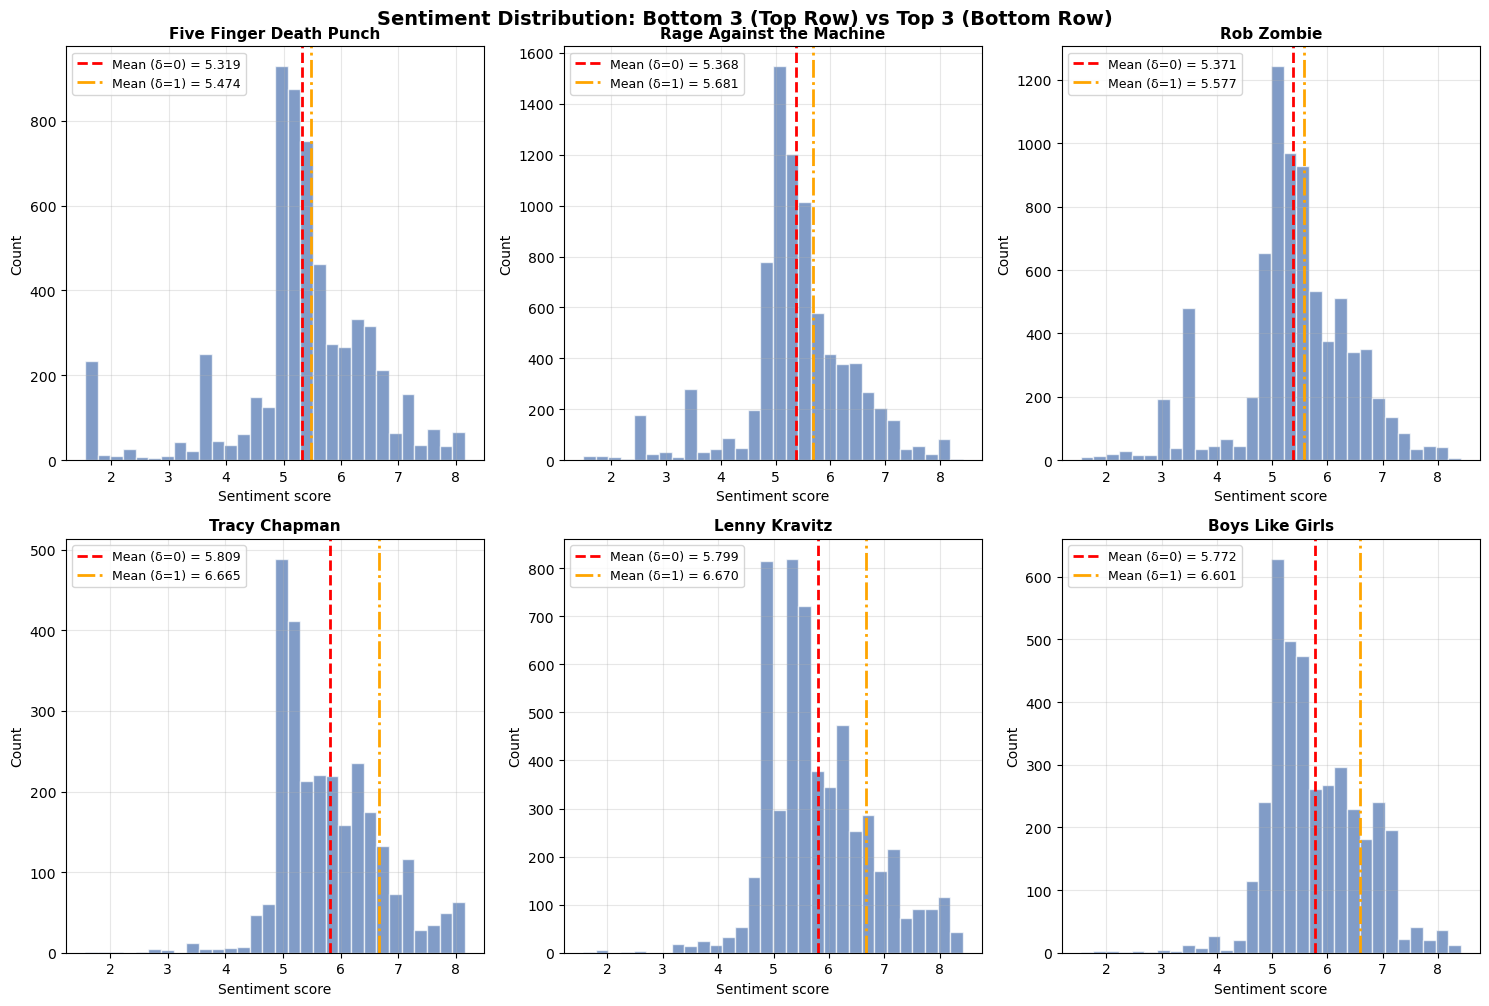

In [39]:
from collections import Counter

import matplotlib.pyplot as plt

# Get all 6 artists (top 3 and bottom 3)
all_artists = list(bottom_3.index) + list(top_3.index)

# Create sentiment dictionary for lookup
sentiment_dict = dict(zip(labmt['word'], labmt['happiness_average']))

# Create 2x3 subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, artist in enumerate(all_artists):
    filename = urllib.parse.quote(artist, safe="")
    with open(f"rock_data/{filename}.txt", "r", encoding="utf-8") as f:
        content = f.read()
        tokens = word_tokenize(content)
        tokens_lower = [token.lower() for token in tokens]
        
        # Get sentiment scores for tokens that exist in LabMT
        sentiments = [sentiment_dict[token] for token in tokens_lower if token in sentiment_dict]
        
        # Plot histogram
        axes[idx].hist(sentiments, bins=30, color="#4C72B0", edgecolor="white", alpha=0.7)
        axes[idx].axvline(artist_sentiments[artist], color="red", linestyle="--", linewidth=2, 
                         label=f"Mean (δ=0) = {artist_sentiments[artist]:.3f}")
        axes[idx].axvline(artist_sentiments_by_delta[1][artist], color="orange", linestyle="-.", linewidth=2, 
                         label=f"Mean (δ=1) = {artist_sentiments_by_delta[1][artist]:.3f}")
        axes[idx].set_title(f"{artist}", fontsize=11, fontweight='bold')
        axes[idx].set_xlabel("Sentiment score")
        axes[idx].set_ylabel("Count")
        axes[idx].legend(fontsize=9)
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("Sentiment Distribution: Bottom 3 (Top Row) vs Top 3 (Bottom Row)", 
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

## 4.2 Statistical Analysis of Sentiment

## 4.3 Visualization of Sentiment Distribution

## 4.4 Sentiment Analysis by Community

## 4.5 Discussion: Connecting TF-IDF and Sentiment Findings

---

## Conclusion

[Summarize the key findings from all four parts of the assignment and reflect on what was learned about the Rock Musicians network.]

---

## References

[Include any references to course materials, libraries, or external sources used in the analysis.]